# ☕ RoasterDB — Starter: Load & Explore Specialty Coffee

A structured dataset of **specialty-coffee products** from curated artisan roasters, with tasting
notes normalized to the **SCA (Specialty Coffee Association) Flavor Wheel** and a **source URL on
every record** so any fact can be re-verified.

This notebook (the **free 100-row sample**) shows how to:
1. Load the data
2. Preview the table and read every column's meaning
3. Explore origins, processing, and price
4. Work with the **SCA flavor mapping** — the differentiated part
5. Trace a record back to its source (provenance)

> **Full dataset:** 8,086 products · 278 roasters · 22 countries · 11,838 SCA flavor mappings →
> [roasterdb.net](https://specialty-coffee-roasterdb.pages.dev)

In [1]:
import os, glob
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

def find_sample():
    # On Kaggle the dataset is mounted under /kaggle/input/<slug>/ — find it
    # regardless of the exact slug. Falls back to local paths off Kaggle.
    for base in ("/kaggle/input", "."):
        hits = glob.glob(os.path.join(base, "**", "roasterdb_sample.csv"), recursive=True)
        if hits:
            return hits[0]
    for p in ("../dataset/roasterdb_sample.csv", "../samples/roasterdb_sample.csv",
              "samples/roasterdb_sample.csv"):
        if os.path.exists(p):
            return p
    return None

path = find_sample()
if path is None and os.path.isdir("/kaggle/input"):
    print("DEBUG - /kaggle/input contains:", os.listdir("/kaggle/input"))
assert path, "Could not locate roasterdb_sample.csv"
df = pd.read_csv(path)
print(f"Loaded {len(df):,} coffees from {df['source_roaster'].nunique()} roasters  ({path})")
df.head()

Loaded 100 coffees from 72 roasters  (../dataset/roasterdb_sample.csv)


,product_id,source_roaster,title,origin_country,origin_region,altitude_min_meters,altitude_max_meters,process_method,roast_level,varietals,weight_grams,price_currency,price_value,tasting_notes_sca_nodes,tasting_notes_confidence,quality_flag,source_platform,source_url,retrieved_at,dataset_version
0,14937669239160,3fe Coffee,"Bolivia - Los Rodriguez: Natural, Longberry",Bolivia,NaN,1700.0,1800.0,Natural,Unknown,NaN,125,USD,18.0,Sweet > Honey > Honey,0.75,good,shopify,https://www.3fe.com/products/bolivia-los-rodri...,2026-07-04 12:37:13,2026.07
1,4461404422249,44 North Coffee,Honduras COMSA,Honduras,Marcala,NaN,NaN,Other,Dark,NaN,227,USD,9.0,Sweet > Brown Sugar > Maple Syrup,0.90,good,shopify,https://44northcoffee.com/products/honduras,2026-07-04 12:40:15,2026.07
2,15325880091010,Assembly Coffee,Mexico — SIPRO,Mexico,NaN,NaN,NaN,Natural,Unknown,NaN,200,USD,13.0,Fruity > Other Fruit > Cherry,0.80,good,shopify,https://assemblycoffee.co.uk/products/mexico-s...,2026-07-04 12:32:21,2026.07
3,9804784075045,Bean There Coffee,Burundi Coffee,Burundi,NaN,NaN,NaN,Honey,Unknown,NaN,250,USD,140.0,Nutty/Cocoa > Cocoa > Chocolate; Sweet > Honey...,0.75,good,shopify,https://beanthere.co.za/products/burundi-coffe...,2026-07-04 12:40:01,2026.07
4,9648336863545,Black & White Coffee Roasters,José Merchán - Delagua Natural,Colombia,NaN,1733.0,1733.0,Anaerobic,Dark,Castillo,354,USD,24.0,Fruity > Berry > Raspberry; Fruity > Other Fru...,0.85,good,shopify,https://www.blackwhiteroasters.com/products/r-...,2026-07-04 12:30:05,2026.07


## Column dictionary

Every field, its type, and what it means. Coverage percentages refer to the **full 8,086-record dataset**
(the sample is the verified tier, so it is more complete).

In [2]:
col_docs = [
    ("product_id",               "string",   "Roaster's Shopify product ID"),
    ("source_roaster",           "string",   "Roaster brand name"),
    ("title",                    "string",   "Coffee / product name as listed"),
    ("origin_country",           "string",   "Producing country (58%)"),
    ("origin_region",            "string",   "Producing region (20%)"),
    ("altitude_min_meters",      "int",      "Min growing elevation, masl (17%)"),
    ("altitude_max_meters",      "int",      "Max growing elevation, masl (17%)"),
    ("process_method",           "enum",     "Washed / Natural / Honey / Anaerobic / Other"),
    ("roast_level",              "enum",     "Light / Medium / Dark (32% specific)"),
    ("varietals",                "string",   "Comma-separated varietals, e.g. 'Gesha, SL28' (30%)"),
    ("weight_grams",             "int",      "Net weight of the listed unit"),
    ("price_currency",           "string",   "Currency code (typically USD)"),
    ("price_value",              "float",    "Retail price, sanitized to $3-$150 (88%)"),
    ("tasting_notes_sca_nodes",  "string",   "'; '-separated SCA paths, e.g. 'Fruity > Berry > Blueberry'"),
    ("tasting_notes_confidence", "float",    "0-1 confidence of the flavor normalization"),
    ("quality_flag",             "enum",     "'good' (verified) or 'questionable'"),
    ("source_platform",          "string",   "Source channel (shopify)"),
    ("source_url",               "string",   "Exact product page the record came from"),
    ("retrieved_at",             "datetime", "Crawl timestamp (when the fact was true)"),
    ("dataset_version",          "string",   "Snapshot id, e.g. 2026.07"),
]
pd.DataFrame(col_docs, columns=["column", "type", "description"])

,column,type,description
0,product_id,string,Roaster's Shopify product ID
1,source_roaster,string,Roaster brand name
2,title,string,Coffee / product name as listed
3,origin_country,string,Producing country (58%)
4,origin_region,string,Producing region (20%)
5,altitude_min_meters,int,"Min growing elevation, masl (17%)"
6,altitude_max_meters,int,"Max growing elevation, masl (17%)"
7,process_method,enum,Washed / Natural / Honey / Anaerobic / Other
8,roast_level,enum,Light / Medium / Dark (32% specific)
9,varietals,string,"Comma-separated varietals, e.g. 'Gesha, SL28' ..."


## Where do these coffees come from?

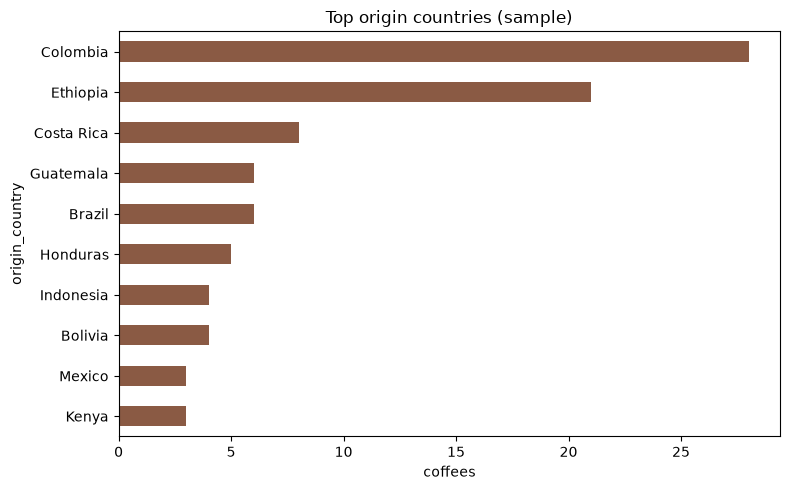

origin_country
Colombia      28
Ethiopia      21
Costa Rica     8
Brazil         6
Guatemala      6
Honduras       5
Bolivia        4
Indonesia      4
Mexico         3
Kenya          3
Name: count, dtype: int64

In [3]:
origins = df["origin_country"].dropna().value_counts().head(10)
ax = origins.sort_values().plot(kind="barh", color="#8a5a44", figsize=(8, 5))
ax.set_title("Top origin countries (sample)")
ax.set_xlabel("coffees")
plt.tight_layout()
plt.show()
origins

## Processing method & price

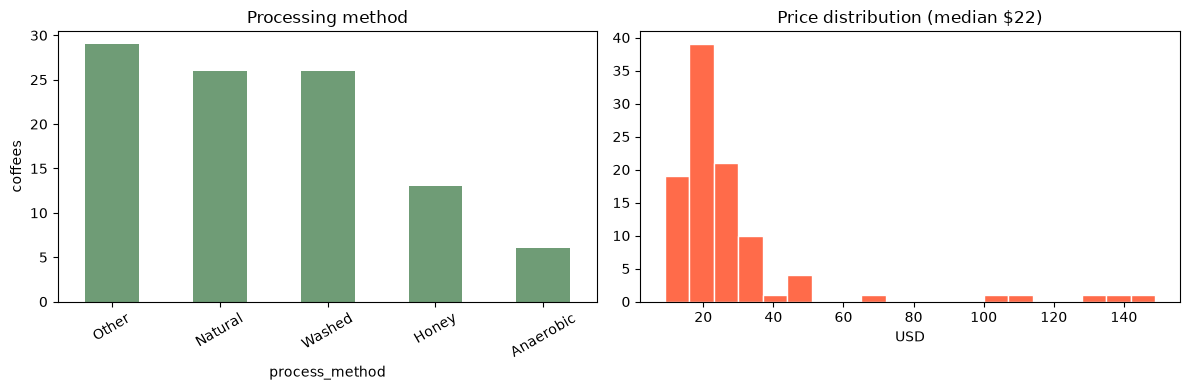

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["process_method"].value_counts().plot(
    kind="bar", ax=axes[0], color="#6f9c76")
axes[0].set_title("Processing method")
axes[0].set_ylabel("coffees")
axes[0].tick_params(axis="x", rotation=30)

prices = df["price_value"].dropna()
axes[1].hist(prices, bins=20, color="#ff6b4a", edgecolor="white")
axes[1].set_title(f"Price distribution (median ${prices.median():.0f})")
axes[1].set_xlabel("USD")
plt.tight_layout()
plt.show()

## The SCA flavor mapping — the differentiated part

Free-text tasting notes are normalized to the SCA 3-tier Flavor Wheel
(`Category > Subcategory > Descriptor`). Multiple nodes per coffee are joined with `; `.
Here we explode them and count the top **top-level flavor categories**.

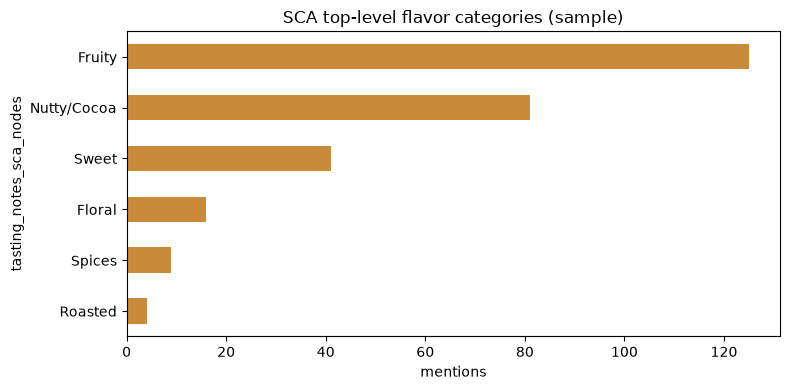

Most common full flavor descriptors:


tasting_notes_sca_nodes
Nutty/Cocoa > Cocoa > Chocolate         42
Fruity > Other Fruit > Cherry           21
Fruity > Other Fruit > Peach            18
Nutty/Cocoa > Cocoa > Dark Chocolate    17
Sweet > Honey > Honey                   15
Fruity > Citrus Fruit > Orange          15
Sweet > Brown Sugar > Caramel           11
Nutty/Cocoa > Cocoa > Milk Chocolate    11
Name: count, dtype: int64

In [5]:
notes = df["tasting_notes_sca_nodes"].dropna()
paths = notes.str.split(r"\s*;\s*").explode().str.strip()
paths = paths[paths != ""]

categories = paths.str.split(">").str[0].str.strip()
top_cat = categories.value_counts()

ax = top_cat.sort_values().plot(kind="barh", color="#c98a3a", figsize=(8, 4))
ax.set_title("SCA top-level flavor categories (sample)")
ax.set_xlabel("mentions")
plt.tight_layout()
plt.show()

print("Most common full flavor descriptors:")
paths.value_counts().head(8)

## Provenance — trace any fact back to its source

Every row carries the exact `source_url` it was extracted from, plus the crawl timestamp.
That is what makes the dataset re-verifiable.

In [6]:
example = df[df["tasting_notes_sca_nodes"].notna()].iloc[0]
print(f"{example['source_roaster']} — {example['title']}")
print(f"  origin : {example['origin_country']} · {example['process_method']} · ${example['price_value']}")
print(f"  flavors: {example['tasting_notes_sca_nodes']}")
print(f"  source : {example['source_url']}")
print(f"  as of  : {example['retrieved_at']}  (snapshot {example['dataset_version']})")

3fe Coffee — Bolivia - Los Rodriguez: Natural, Longberry
  origin : Bolivia · Natural · $18.0
  flavors: Sweet > Honey > Honey
  source : https://www.3fe.com/products/bolivia-los-rodriguez-natural-longberry
  as of  : 2026-07-04 12:37:13  (snapshot 2026.07)


## Get the full dataset

This is the free 100-row sample. The full **8,086-record** dataset — SQLite + CSV + JSON,
with 11,838 SCA flavor mappings and a 3,422-record verified tier — is available at:

### → [roasterdb.net](https://specialty-coffee-roasterdb.pages.dev)

Custom roaster targets, recurring refreshes, or API access: **RoasterDB@proton.me**